# 08 · CCA: campañas aleatorias con 5 % de ataques y varios flips

**Objetivo:** comparar Base, A y B cuando algunas lecturas de CCA sufren ataques de tamaños distintos. La campaña afecta a una serie completa; todos los ataques de un mismo día intervienen juntos en su máximo.

**N significa cuántos bits distintos se invierten dentro de un mensaje atacado.** Por ejemplo, N = 3 significa tres inversiones en esa lectura. No significa tres lecturas ni tres días. En los archivos, N = 0 identifica una lectura sin ataque.

Reutilizamos las **predicciones y el p95 guardados de CCA del notebook 09**, sin entrenar ni hacer nueva inferencia. El modelo del 09 ya utilizaba variables de red; aquí sólo evaluamos y atacamos CCA, con esas entradas y predicciones congeladas. No se entrena un modelo nuevo de una sola variable.

## 1. Los tres sorteos

Para cada lectura válida del periodo de prueba:

1. **¿Hay ataque?** Sí con probabilidad 5 %; no con 95 %. El número final no tiene que ser exactamente el 5 %.
2. **Si hay ataque, ¿cuántos bits?** Se elige N entre 1 y 16, con igual probabilidad para cada número.
3. **¿Qué posiciones?** Se eligen N posiciones distintas del campo de 16 bits del valor, uniformemente y sin repetir una posición.

Se incluyen bits de pesos sin repartir, como 64 y 128, y las posiciones reservadas. El alcance es el campo del valor; no toda la trama LoRaWAN. Cada ataque pasa por codificar → cifrar → invertir bits → descifrar → decodificar en el modelo de amenaza del proyecto.

Una **semilla aleatoria** permite reproducir los sorteos. No se introduce un nonce criptográfico nuevo. Se usan tres generadores independientes y se guarda el plan de ataques. El sorteo no consulta la concentración, predicción ni estado de los bits.

**Comparación pareada:** Base, A y B reciben exactamente los mismos momentos de ataque, N y posiciones. La lectura legítima es idéntica en los tres. Las diferencias surgen de la representación y sus reglas de aceptación.

**Repeticiones:** 100 campañas con semillas 42…141. La semilla 42 se fija desde el principio como ejemplo visual; no se elige por sus resultados.

## 2. Qué cambia respecto al experimento 07

El 07 enumeraba combinaciones para cada mensaje por separado. Aquí generamos una campaña concreta por semilla: la serie contiene lecturas limpias, ataques aceptados y rechazos.

- Se ataca sólo el periodo de prueba con predicciones persistidas, después del corte de entrenamiento.
- Los datos raw ausentes no se convierten en mensajes ni se atacan.
- Para la detección inmediata se conserva la predicción original de cada instante. **No se simula la propagación de ataques o pérdidas a futuras entradas, perfiles o predicciones.**
- El máximo diario es **sólo de CCA**. No se reutiliza el máximo de la red ni se interpreta como una declaración oficial.
- Una alerta del LSTM se registra; no retira automáticamente la lectura del máximo diario.
- Un rechazo sí deja una lectura ausente. No se reemplaza por cero. Si un día se quedara sin datos, su banda sería indefinida y se contaría aparte.

In [2]:
from pathlib import Path
import sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

actual=Path.cwd().resolve()
RAIZ=next(p for p in (actual,*actual.parents) if (p/'experiments/cayenne_mod/campana_cca.py').is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0,str(RAIZ))
from experiments.cayenne_mod import campana_cca
campana_cca=importlib.reload(campana_cca)
pd.set_option('display.max_columns',20)
pd.set_option('display.width',180)

## 3. Ejecutar dos veces antes de aceptar los resultados

Se verifican los hashes de las fuentes guardadas del 09 y se comprueba que las lecturas CCA coincidan con el raw. Cada ataque cifrado se contrasta con la máscara esperada. Después se repiten las 100 campañas y se exige igualdad exacta de todas las tablas.

Los productos nuevos se guardan en `resultados/08/`. Las predicciones y los experimentos anteriores se conservan.

In [3]:
resultados,info=campana_cca.construir(RAIZ)
otra,info2=campana_cca.construir(RAIZ)
assert info==info2
for nombre in resultados:
    pd.testing.assert_frame_equal(resultados[nombre],otra[nombre],check_exact=True)
del otra
info['reproducibilidad']='Dos ejecuciones completas de las 100 campañas; tablas exactamente iguales'
DESTINO=campana_cca.guardar(RAIZ,resultados,info)
print('Predicciones y p95 GUARDADOS de CCA del notebook 09; sin entrenamiento ni inferencia nueva.')
print(f"Periodo: {info['inicio']} a {info['fin']}.")
print(f"{info['horas_periodo']} horas: {info['n_mensajes']} lecturas válidas y {info['faltantes_raw']} ausentes; {info['n_dias']} días.")
print(f"Umbral de esta referencia CCA: {info['umbral_ppb']:.6f} ppb. El piloto de 22.6 ppb es otra referencia.")
print(f"Sin ataques: {info['alertas_limpias']} alertas de {info['n_mensajes']} lecturas ({info['fpr_limpio_pct']:.2f}%).")
print(f"Dos ejecuciones idénticas. {info['transformaciones_cifradas']:,} ataques cifrados verificados por ejecución.")
print(f"Resultados: {DESTINO.relative_to(RAIZ)}")

Predicciones y p95 GUARDADOS de CCA del notebook 09; sin entrenamiento ni inferencia nueva.
Periodo: 2025-10-21 00:00:00 a 2025-12-31 23:00:00.
1728 horas: 1684 lecturas válidas y 44 ausentes; 72 días.
Umbral de esta referencia CCA: 14.748355 ppb. El piloto de 22.6 ppb es otra referencia.
Sin ataques: 360 alertas de 1684 lecturas (21.38%).
Dos ejecuciones idénticas. 25,131 ataques cifrados verificados por ejecución.
Resultados: experiments/cayenne_mod/resultados/08


## 4. Un ejemplo concreto: semilla 42

Primero leemos una campaña, sin promediar. Los tres formatos reciben el mismo número de ataques.

**Rechazados + cancelados + valores alterados = ataques intentados.**

- **Rechazado:** se perdió la lectura; la alerta LSTM es indefinida.
- **Cancelado:** se modificó el payload pero el valor recibido quedó igual. Si ya tenía una alarma limpia, no la contamos como detección de un valor alterado.
- **Alterado:** cambió el valor numérico. Puede generar alerta o no; además puede cambiar su banda local o no.
- **Banda local sin alerta:** la lectura aceptada cambia de banda y su residuo no supera el p95. No se incluyen rechazos.

La **banda local** se refiere a esa lectura. El máximo diario se analiza por separado.

In [4]:
res=resultados['resumen_por_semilla']
s42=res.query('semilla == 42')
cols={'formato':'Formato','ataques':'Ataques','rechazos':'Rechazados',
      'cancelaciones':'Valor intacto','alterados':'Valores alterados',
      'detectados_alterados':'Alterados con alerta','banda_local_sin_alerta':'Banda local sin alerta'}
display(s42[list(cols)].rename(columns=cols).reset_index(drop=True))
print(f"Semilla 42: {int(s42.ataques.iloc[0])} ataques de {info['n_mensajes']} lecturas ({s42.tasa_real_ataque_pct.iloc[0]:.2f}%).")
print('Esta campaña es un ejemplo. Un cero aquí no demuestra que el escape sea imposible.')

,Formato,Ataques,Rechazados,Valor intacto,Valores alterados,Alterados con alerta,Banda local sin alerta
0,base,81,76,0,5,5,0
1,A,81,73,0,8,7,0
2,B,81,70,0,11,10,0


Semilla 42: 81 ataques de 1684 lecturas (4.81%).
Esta campaña es un ejemplo. Un cero aquí no demuestra que el escape sea imposible.


### Seguir los primeros cinco ataques lectura por lectura

En la tabla, `bits` son las posiciones físicas elegidas y `N` su cantidad. La semilla no conoce el valor original para elegirlas. Las columnas original, recibido y alerta nos permiten auditar lo que pasó después.

Un recibido vacío y una alerta vacía indican **rechazo**, no una lectura cero ni una detección del LSTM.

In [5]:
plan=resultados['plan_ataques'].query('semilla == 42').sort_values('timestamp').head(5)
at=resultados['ataques'].query('semilla == 42').merge(plan[['id_mensaje','bits']],on='id_mensaje')
at['resultado']=np.select([at.rechazos,at.cancelaciones],['Rechazo','Valor intacto'],default='Valor alterado')
cols={'timestamp':'Momento','formato':'Formato','original_ppb':'Original','n_flips':'N','bits':'Posiciones',
      'recibido_ppb':'Recibido','delta_ppb':'Cambio','resultado':'Resultado','alerta':'Alerta LSTM'}
display(at.sort_values(['timestamp','formato'])[list(cols)].rename(columns=cols).reset_index(drop=True))

,Momento,Formato,Original,N,Posiciones,Recibido,Cambio,Resultado,Alerta LSTM
0,2025-10-21 17:00:00,A,32.0,11,"0,1,2,4,6,8,10,12,13,14,15",NaN,NaN,Rechazo,<NA>
1,2025-10-21 17:00:00,B,32.0,11,"0,1,2,4,6,8,10,12,13,14,15",NaN,NaN,Rechazo,<NA>
2,2025-10-21 17:00:00,base,32.0,11,"0,1,2,4,6,8,10,12,13,14,15",NaN,NaN,Rechazo,<NA>
3,2025-10-22 12:00:00,A,44.0,13,"1,3,4,6,7,8,9,10,11,12,13,14,15",NaN,NaN,Rechazo,<NA>
4,2025-10-22 12:00:00,B,44.0,13,"1,3,4,6,7,8,9,10,11,12,13,14,15",NaN,NaN,Rechazo,<NA>
5,2025-10-22 12:00:00,base,44.0,13,"1,3,4,6,7,8,9,10,11,12,13,14,15",NaN,NaN,Rechazo,<NA>
6,2025-10-22 23:00:00,A,12.0,2,"6,13",NaN,NaN,Rechazo,<NA>
7,2025-10-22 23:00:00,B,12.0,2,"6,13",NaN,NaN,Rechazo,<NA>
8,2025-10-22 23:00:00,base,12.0,2,"6,13",NaN,NaN,Rechazo,<NA>
9,2025-10-23 20:00:00,A,19.0,9,"0,1,4,6,7,10,12,14,15",NaN,NaN,Rechazo,<NA>


## 5. Las 100 campañas: no depender de un solo sorteo

Cada campaña vuelve a partir de la misma serie limpia. Las semillas cambian los ataques, no los datos de contaminación ni el modelo. Por ello, **100 campañas no equivalen a 100 periodos independientes**.

La media puede tener decimales: por ejemplo, 0.19 eventos por campaña significa 19 eventos acumulados entre 100 campañas. No significa que exista una fracción de ataque en una ejecución.

Los percentiles p05 y p95 describen la variación entre estos sorteos; **no son intervalos de confianza de una población futura**.

In [6]:
cols={'ataques':'Ataques','rechazos':'Rechazados','cancelaciones':'Valor intacto',
      'alterados':'Valores alterados','detectados_alterados':'Alterados con alerta',
      'banda_local_sin_alerta':'Banda local sin alerta','falsas_alarmas_limpios':'Falsas alarmas en limpios'}
prom=res.groupby('formato',sort=False)[list(cols)].mean().rename(columns=cols)
display(prom.round(2))
est=resultados['estadisticas']
display(Markdown('**Variación del número de lecturas que cambian banda sin alerta:**'))
display(est.query("metrica == 'banda_local_sin_alerta'")[['formato','media','p05','p95','minimo','maximo']].reset_index(drop=True))
display(Markdown('**Comparación pareada: propuesta menos Base en cada semilla:**'))
display(resultados['pareados'].query("metrica == 'banda_local_sin_alerta'")
        [['formato','diferencia_media_vs_base','semillas_menor','semillas_igual','semillas_mayor']].reset_index(drop=True))
print('Menor = menos lecturas con cambio de banda sin alerta que Base; igual = empate; mayor = más.')

,Ataques,Rechazados,Valor intacto,Valores alterados,Alterados con alerta,Banda local sin alerta,Falsas alarmas en limpios
formato,,,,,,,
base,83.77,79.57,0.00,4.20,2.79,0.13,341.74
A,83.77,76.68,0.05,7.04,4.44,0.16,341.74
B,83.77,71.66,0.29,11.82,7.72,0.19,341.74


**Variación del número de lecturas que cambian banda sin alerta:**

,formato,media,p05,p95,minimo,maximo
0,base,0.13,0.0,1.0,0.0,1.0
1,A,0.16,0.0,1.0,0.0,2.0
2,B,0.19,0.0,1.0,0.0,2.0


**Comparación pareada: propuesta menos Base en cada semilla:**

,formato,diferencia_media_vs_base,semillas_menor,semillas_igual,semillas_mayor
0,A,0.03,6,85,9
1,B,0.06,8,81,11


Menor = menos lecturas con cambio de banda sin alerta que Base; igual = empate; mayor = más.


## 6. N por separado: por qué hay tantos rechazos

Base tiene 8 posiciones activas y 8 reservadas; A tiene 10 activas y 6 reservadas; B tiene 12 activas y 4 reservadas. Elegir más posiciones aumenta la posibilidad de tocar alguna reservada.

Con N = 16 se invierten todas: los tres formatos rechazan. Con N mayor que el número de posiciones activas, el rechazo también es inevitable. Esto no depende de la capacidad del LSTM.

Elegir **N uniforme entre 1 y 16** da la mitad de los ataques a N entre 9 y 16. Es una distribución de severidad concreta, no una descripción comprobada de un atacante real. Mostramos los resultados por N para no esconder ese efecto dentro del promedio.

Las tasas condicionadas a valores alterados quedan vacías si no hay ninguno: un vacío no significa 100 % de detección. Con 5 % de ataques habrá presupuestos con pocas alteraciones aceptadas.

Un 100 % de detección con muy pocos valores alterados no acredita robustez general. Consultar siempre la columna «Valores alterados» en los conteos completos por N.

In [7]:
pn=resultados['resumen_por_n']
cols={'formato':'Formato','n_flips':'N','ataques':'Intentos en 100 campañas','rechazos':'Rechazados',
      'alterados':'Valores alterados','banda_local_sin_alerta':'Banda local sin alerta',
      'recall_alterados_pct':'Alterados detectados (%)','rechazo_teorico_pct':'Rechazo teórico (%)'}
display(pn.loc[pn.n_flips.isin([1,2,3,4,8,12,16]),list(cols)]
        .sort_values(['n_flips','formato']).rename(columns=cols).round(2).reset_index(drop=True))
print('Todos los N: resultados/08/resumen_por_n.csv. Los conteos suman las campañas, no son una sola serie.')

,Formato,N,Intentos en 100 campañas,Rechazados,Valores alterados,Banda local sin alerta,Alterados detectados (%),Rechazo teórico (%)
0,A,1,493,198,295,7,43.73,37.50
1,B,1,493,131,362,8,39.23,25.00
2,base,1,493,256,237,6,57.38,50.00
3,A,2,520,336,181,4,67.96,62.50
4,B,2,520,253,239,5,63.60,45.00
5,base,2,520,407,113,5,70.80,76.67
6,A,3,503,386,115,3,80.87,78.57
7,B,3,503,287,216,3,69.44,60.71
8,base,3,503,453,50,2,86.00,90.00
9,A,4,507,460,47,0,87.23,88.46


Todos los N: resultados/08/resumen_por_n.csv. Los conteos suman las campañas, no son una sola serie.


## 7. Máximo diario: varios ataques actúan juntos

El máximo se calcula con las lecturas disponibles de CCA después de aplicar **todos los ataques de la campaña**. Una lectura detectada sigue en el cálculo: no hemos definido una política de eliminación por alerta.

Para entender el origen de las diferencias, calculamos tres versiones:

| Versión | Qué hacemos |
|---|---|
| Disponibles | Usamos valores recibidos; omitimos lecturas rechazadas |
| Sólo cambios de valor | Aplicamos alteraciones aceptadas; restauramos el original de los rechazos |
| Sólo pérdidas | Quitamos rechazos; conservamos el original de las demás lecturas |

Las dos últimas son **referencias explicativas del simulador**, que conoce los originales. No son soluciones disponibles para el receptor. Sus efectos pueden interactuar; sus conteos no tienen por qué sumar el resultado de disponibles.

Un día con banda distinta **no equivale automáticamente a un daño sin alerta**. La detección se mide por lectura; esta tabla mide el efecto diario, independientemente de las alertas.

**Ejemplo:** con lecturas 60, 59 y 20, el máximo original es 60. Si dos ataques transforman las primeras en 28 y 27, el máximo queda en 28. Evaluar sólo uno de esos ataques habría dejado un máximo de 59 o 60; por eso aquí aplicamos la campaña completa antes de calcular el máximo.

In [8]:
cols={'dias_cambio_banda_disponibles':'Días con banda distinta: disponibles',
      'dias_cambio_banda_solo_valores':'Días con banda distinta: sólo valores',
      'dias_cambio_banda_solo_perdidas':'Días con banda distinta: sólo pérdidas',
      'dias_dia_con_perdida':'Días con alguna lectura rechazada','dias_dia_sin_datos':'Días sin datos'}
display(res.groupby('formato',sort=False)[list(cols)].mean().rename(columns=cols).round(2))
print(f"Promedios de días por campaña. Cada campaña cubre {info['n_dias']} días.")
dia=resultados['diario']
print('Detalle de los primeros días cuya banda cambia en B, semilla 42:')
display(dia.query("semilla == 42 and formato == 'B' and cambio_banda_disponibles")
        [['fecha','ataques','rechazos','maximo_original','maximo_recibido','banda_original','banda_recibida',
          'alertas_en_valores_alterados']].head(5).reset_index(drop=True))
print('Bandas: 0 Buena, 1 Aceptable, 2 Mala, 3 Muy mala, 4 Extremadamente mala.')

,Días con banda distinta: disponibles,Días con banda distinta: sólo valores,Días con banda distinta: sólo pérdidas,Días con alguna lectura rechazada,Días sin datos
formato,,,,,
base,1.33,1.04,0.29,48.86,0.0
A,2.17,1.89,0.27,47.86,0.0
B,3.66,3.40,0.26,46.11,0.0


Promedios de días por campaña. Cada campaña cubre 72 días.
Detalle de los primeros días cuya banda cambia en B, semilla 42:


,fecha,ataques,rechazos,maximo_original,maximo_recibido,banda_original,banda_recibida,alertas_en_valores_alterados
0,2025-10-24,2,1,126.0,155.0,2,3,1
1,2025-10-25,1,0,119.0,143.0,2,3,1
2,2025-11-15,2,0,87.0,91.0,1,2,2
3,2025-12-09,2,1,86.0,100.0,1,2,1
4,2025-12-10,2,1,84.0,143.0,1,3,1


Bandas: 0 Buena, 1 Aceptable, 2 Mala, 3 Muy mala, 4 Extremadamente mala.


## 8. Gráficas

1. Variación entre las 100 campañas: cada punto es una campaña completa.
2. Resultados separados por N, juntando los conteos de las 100 campañas.
3. Serie de la semilla 42: primeros 14 días, elegidos por fecha. Las cruces muestran el valor original de lecturas perdidas sólo para inspección; no son valores que recibió el detector.

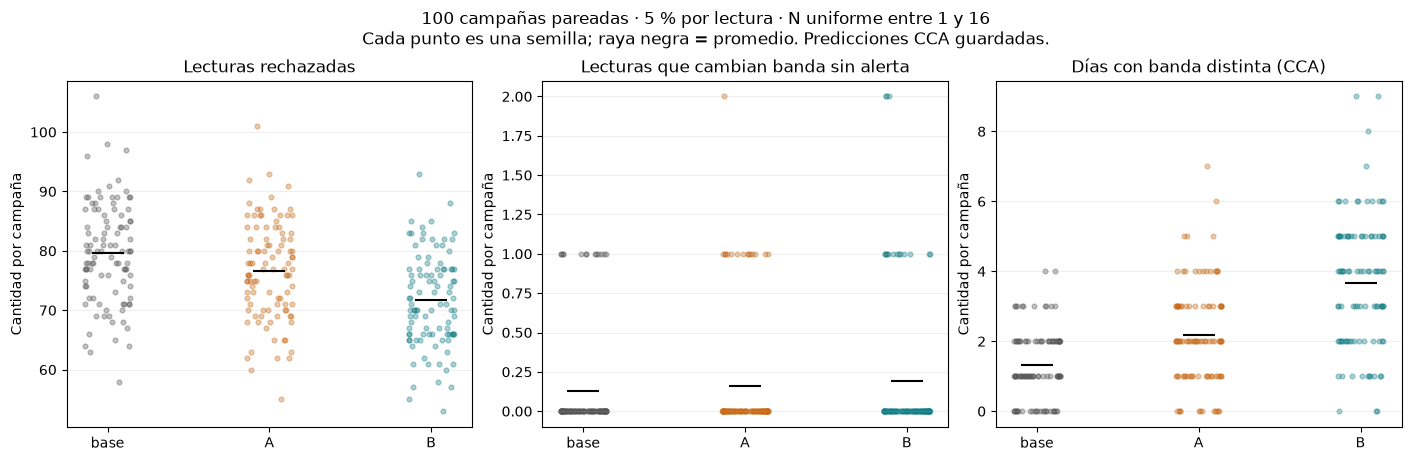

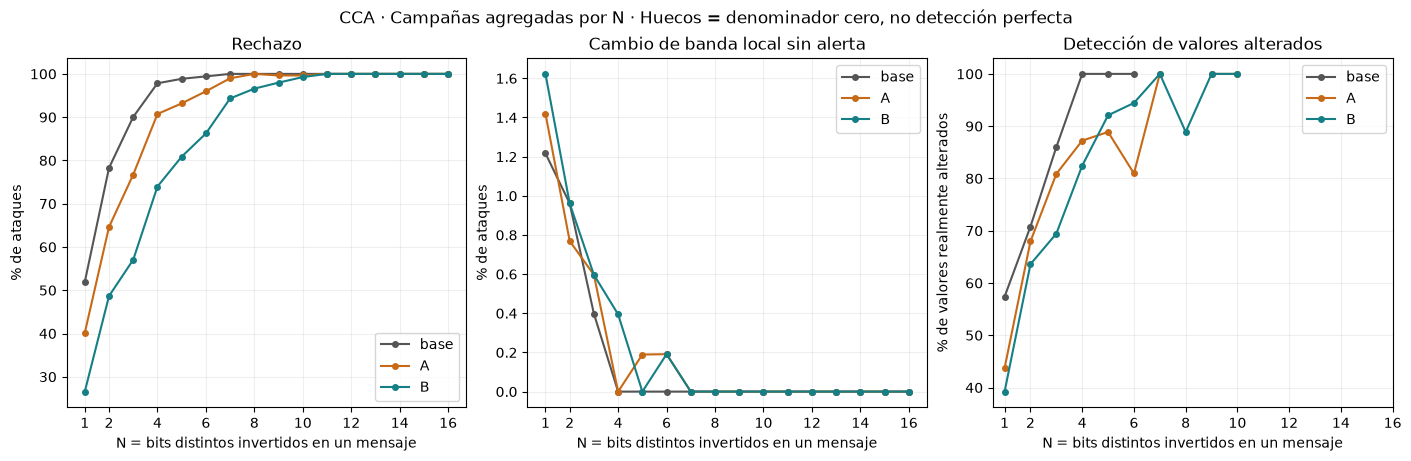

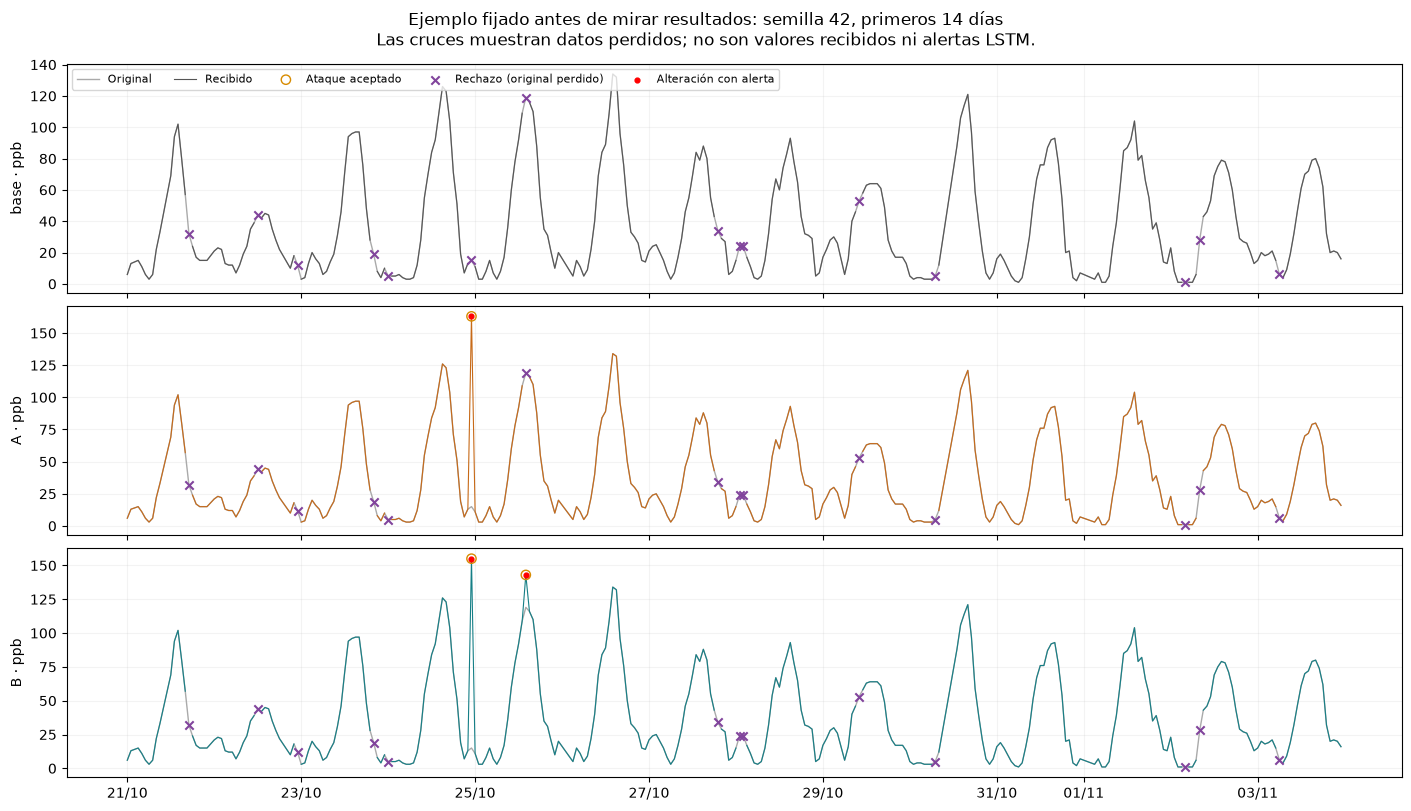

In [9]:
campana_cca.graficar(resultados,info,DESTINO)
plt.show()

## 9. Qué ocurrió en estas campañas

**No se observa una reducción clara del daño sin alerta con B bajo esta distribución de ataques.**

- En promedio hubo **83.77 ataques por campaña**. Base rechazó 79.57, A rechazó 76.68 y B rechazó 71.66. B conserva más lecturas, aunque algunas llegan alteradas.
- Sumando las 100 campañas hubo **13 lecturas con banda local cambiada sin alerta en Base, 16 en A y 19 en B**. Son conteos pequeños: B mejoró frente a Base en 8 semillas, empató en 81 y empeoró en 11. No se demuestra superioridad estadística.
- Entre ataques aceptados, B tuvo una proporción menor de cambios de banda sin alerta (**1.57 % frente a 3.10 % de Base**). Pero B acepta más ataques: esa proporción menor no produjo menos escapes totales.
- El máximo diario disponible cambió de banda en **1.33 días por campaña en Base, 2.17 en A y 3.66 en B**. Estos días incluyen alteraciones detectadas; no se deben presentar como días de daño sin alerta.
- La semilla 42 por sí sola dio cero cambios de banda local sin alerta en los tres formatos. Las repeticiones muestran por qué no basta mirar una sola campaña.

### Límites de la interpretación

El experimento pregunta si las representaciones se comportan de forma distinta bajo **5 % de selección, N uniforme 1…16 y posiciones uniformes**. No demuestra que ese patrón sea el más frecuente en el mundo real.

El detector guardado ya produce falsas alarmas sobre datos limpios. Hay que mostrar esas alarmas junto a las detecciones de ataques: muchas alertas en la serie no significan necesariamente buena detección del ataque.

Los rechazos se cuentan como pérdida de datos y pueden alterar el máximo diario si desaparecen lecturas altas. No se atribuyen al LSTM como detecciones exitosas.

El máximo original de CCA en este periodo es menor que 155 ppb. Por ello, no se puede evaluar aquí el ocultamiento de excedencias originales de ese umbral; sus ceros no acreditan protección. Las falsas excedencias sí pueden aparecer después de un ataque.

Este análisis conserva predicciones originales. Antes de trasladar una conclusión al funcionamiento continuo, faltan la propagación a ventanas futuras, una política de tratamiento de rechazos/alertas y otro periodo de validación.

Los archivos permiten auditar cada paso: `plan_ataques.csv` contiene momentos, N, máscaras y posiciones; `ataques.csv.gz` contiene sus efectos en cada formato; `serie_ejemplo.csv.gz` incluye todas las lecturas de la semilla 42; `diario.csv.gz` reúne los máximos; `protocolo.json` documenta fuentes y reproducibilidad.

[Resumen para la junta](avance_junta_08.md).

In [10]:
display(Markdown('**Excedencias de 155 ppb: conteos por lectura, acumulados en las 100 campañas**'))
display(res.groupby('formato',sort=False)[['falsa_excedencia','falsa_excedencia_sin_alerta',
                                         'ocultamiento','ocultamiento_sin_alerta']].sum())
print(f"Máximo original de CCA en el periodo: {info['maximo_limpio_ppb']:.0f} ppb.")

**Excedencias de 155 ppb: conteos por lectura, acumulados en las 100 campañas**

,falsa_excedencia,falsa_excedencia_sin_alerta,ocultamiento,ocultamiento_sin_alerta
formato,,,,
base,57,0,0,0
A,117,0,0,0
B,214,1,0,0


Máximo original de CCA en el periodo: 145 ppb.
